Decision Tree 정확도 : 1.0000


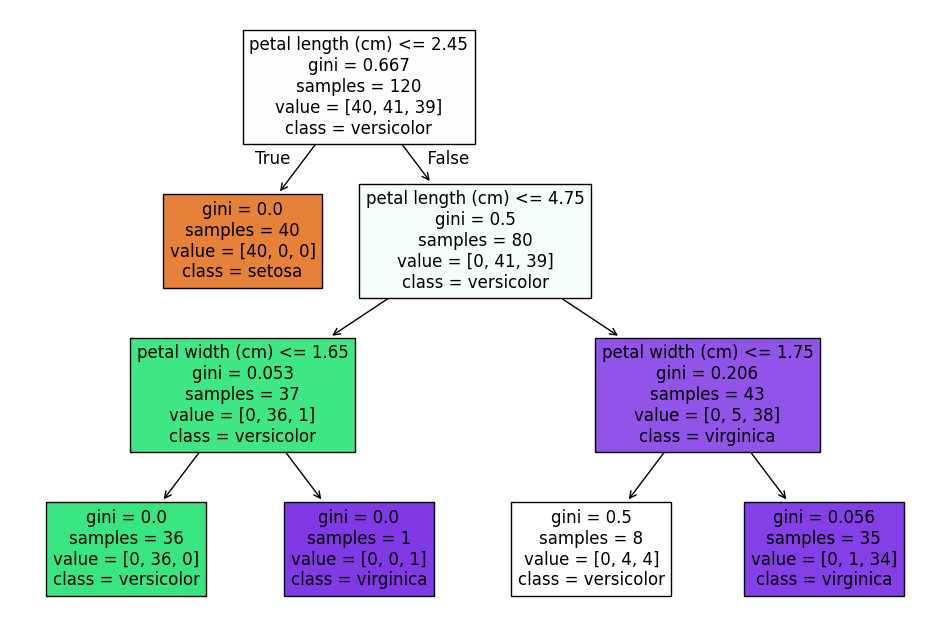

In [1]:
import pandas as pd

# 결정트리 모델
from sklearn.tree import DecisionTreeClassifier

# 데이터셋
from sklearn.datasets import load_iris

# 데이터 분할
from sklearn.model_selection import train_test_split

# 성능 평가
from sklearn.metrics import accuracy_score

# 트리 시각화
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


# 1️⃣ 데이터 로드
iris = load_iris()

X = iris.data
y = iris.target



#Train 성능은 높은데 Test 성능이 낮다 → 과적합" 을 가장 먼저 판단
# 2️⃣ 모델 생성
dt = DecisionTreeClassifier(
    max_depth=3,        # 트리 깊이 제한 (과적합 방지)
    random_state=42
)


# 3️⃣ 데이터 분할
train_x, test_x, train_y, test_y = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# 4️⃣ 모델 학습
dt.fit(train_x, train_y)


# 5️⃣ 예측
pred = dt.predict(test_x)


# 6️⃣ 성능 평가
print('Decision Tree 정확도 : {:.4f}'.format(
    accuracy_score(test_y, pred)
))


# 7️⃣ 트리 시각화
plt.figure(figsize=(12, 8))
plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.show()

Train 정확도 : 0.9583
Test 정확도  : 1.0

성능 차이 : -0.0417
→ 과적합 아님


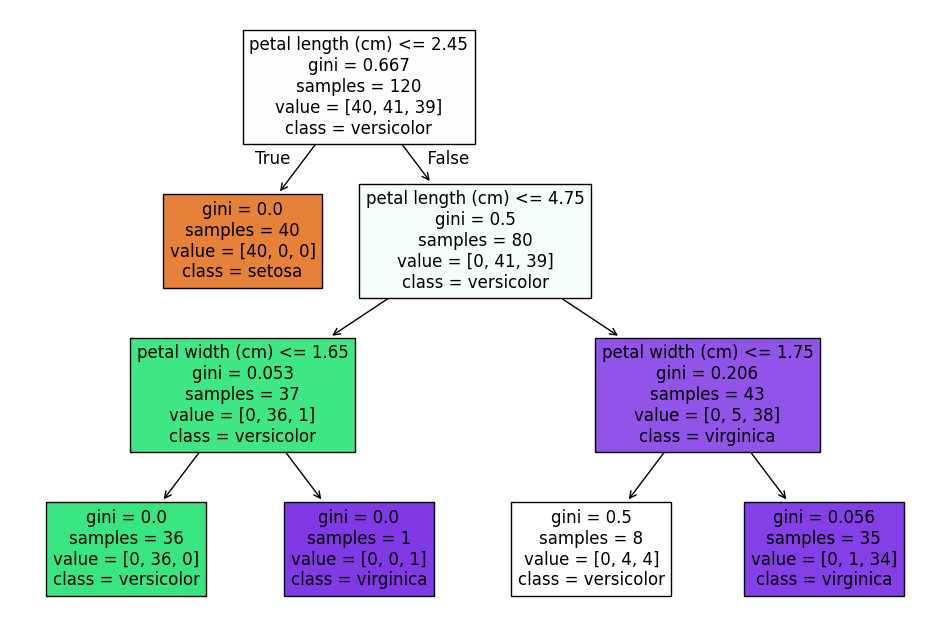

In [2]:
# 과적합 판단

import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


# 1 데이터 로드
iris = load_iris()

X = iris.data
y = iris.target


# 2 모델 생성
dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)


# 3 데이터 분할
train_x, test_x, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# 4 학습
dt.fit(train_x, train_y)


# 5 예측
train_pred = dt.predict(train_x)
test_pred = dt.predict(test_x)


# 6 성능 평가
train_acc = accuracy_score(train_y, train_pred)
test_acc = accuracy_score(test_y, test_pred)

print("Train 정확도 :", round(train_acc, 4))
print("Test 정확도  :", round(test_acc, 4))


# 과적합 판단
gap = train_acc - test_acc

print("\n성능 차이 :", round(gap, 4))

if gap > 0.1:
    print("→ 과적합 의심")
elif gap > 0.03:
    print("→ 약간 과적합 가능")
else:
    print("→ 과적합 아님")


# 7 시각화
plt.figure(figsize=(12,8))
plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()
